In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importing Required Libraries

The first step of this project is importing all the required Python libraries for data analysis and visualization.

Pandas is used for data manipulation and preprocessing.

NumPy provides numerical computing functions.

Matplotlib is used to create basic visualizations.

Seaborn is used to generate advanced statistical graphics with better aesthetics.

These libraries provide the foundation for performing Exploratory Data Analysis (EDA) efficiently.

In [2]:
df=pd.read_csv("education.csv" , encoding="latin1")
df.head()

,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
0,1,Harvard University,USA,1,2,1,1,1,1,1,1,100.0
1,2,Stanford University,USA,2,10,3,2,10,4,3,2,96.7
2,3,Massachusetts Institute of Technology,USA,3,3,11,3,30,15,2,6,95.1
3,4,University of Cambridge,United Kingdom,1,5,19,6,12,8,6,19,94.0
4,5,University of Oxford,United Kingdom,2,9,25,10,9,5,7,4,93.2


Loading the Dataset

The dataset is imported into a Pandas DataFrame using the read_csv() function.
After loading the dataset, it becomes available for further preprocessing, statistical analysis, and visualization. At this stage, no modifications are made to the original data.

Displaying the First Rows of the Dataset

The head() function is used to display the first five rows of the dataset.
This initial inspection helps verify that the dataset has been loaded correctly and provides an overview of the available variables, their formats, and the overall structure of the data before starting the cleaning process.

In [3]:
df.shape

(1000, 12)

Dataset Dimensions

The shape attribute is used to determine the size of the dataset by displaying the total number of rows and columns.
Knowing the dataset dimensions provides a quick overview of the data volume and helps estimate the complexity of the analysis. It also allows us to verify whether the dataset has been loaded correctly before starting the preprocessing stage.

In [4]:
table1=pd.DataFrame(df)
table1

,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
0,1,Harvard University,USA,1,2,1,1,1,1,1,1,100.0
1,2,Stanford University,USA,2,10,3,2,10,4,3,2,96.7
2,3,Massachusetts Institute of Technology,USA,3,3,11,3,30,15,2,6,95.1
3,4,University of Cambridge,United Kingdom,1,5,19,6,12,8,6,19,94.0
4,5,University of Oxford,United Kingdom,2,9,25,10,9,5,7,4,93.2
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Aga Khan University,Pakistan,3,-,> 1000,-,> 1000,> 1000,464,673,69.8
996,997,University of Calcutta,India,17,353,716,296,798,966,> 1000,> 1000,69.8
997,998,K?chi University,Japan,56,-,> 1000,-,> 1000,> 1000,811,673,69.8
998,999,Soonchunhyang University,South Korea,35,-,> 1000,-,881,> 1000,> 1000,898,69.8


In [5]:
table1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   World Rank            1000 non-null   int64  
 1   Institution           1000 non-null   object 
 2   Location              1000 non-null   object 
 3   National Rank         1000 non-null   int64  
 4   Quality of Education  1000 non-null   object 
 5   Alumni Employment     1000 non-null   object 
 6   Quality of Faculty    1000 non-null   object 
 7   Research Output       1000 non-null   object 
 8   Quality Publications  1000 non-null   object 
 9   Influence             1000 non-null   object 
 10  Citations             1000 non-null   object 
 11  Score                 1000 non-null   float64
dtypes: float64(1), int64(2), object(9)
memory usage: 93.9+ KB


Dataset Information

The info() function provides a summary of the dataset, including the column names, data types, number of non-null values, and memory usage.
This step is essential because it helps identify missing values and detect columns with incorrect data types. In this dataset, several ranking columns were stored as object data types instead of numeric values, indicating that additional preprocessing was required before analysis.

In [6]:
print(df.columns.tolist())

['World Rank', 'Institution', 'Location', 'National Rank', 'Quality\xa0of Education', 'Alumni Employment', 'Quality\xa0of Faculty', 'Research Output', 'Quality Publications', 'Influence', 'Citations', 'Score']


In [7]:
# define
def clean_rank_value(x, threshold=1000):
    s = str(x).strip().replace('\xa0', '')
    if s == '-' or s == '':
        return np.nan
    if s.startswith('>'):
        return threshold + 1
    if s.startswith('<'):
        return threshold - 1
    try:
        return float(s)
    except:
        return np.nan

# identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# apply function on numerical columns
for col in numerical_cols:
    df[col] = df[col].apply(clean_rank_value, threshold=1000)

# Ensure that non-numeric columns are not changed
print(df[['Location', 'Institution']].head()) 

         Location                            Institution
0             USA                     Harvard University
1             USA                    Stanford University
2             USA  Massachusetts Institute of Technology
3  United Kingdom                University of Cambridge
4  United Kingdom                   University of Oxford


In [8]:
df.columns = df.columns.str.strip().str.replace('\xa0', ' ', regex=True)

In [9]:
# List of columns that need cleaning
#convert
columns_to_clean = [
    'Quality of Education',
    'Alumni Employment',
    'Quality of Faculty',
    'Research Output',
    'Quality Publications',
    'Influence',
    'Citations'
]

# Apply the cleaning function to each column
for col in columns_to_clean:
    df[col] = df[col].apply(clean_rank_value)

In [10]:
print(df[columns_to_clean].info())
print(df[columns_to_clean].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Quality of Education  403 non-null    float64
 1   Alumni Employment     1000 non-null   float64
 2   Quality of Faculty    269 non-null    float64
 3   Research Output       1000 non-null   float64
 4   Quality Publications  1000 non-null   float64
 5   Influence             1000 non-null   float64
 6   Citations             1000 non-null   float64
dtypes: float64(7)
memory usage: 54.8 KB
None
       Quality of Education  Alumni Employment  Quality of Faculty  \
count            403.000000        1000.000000          269.000000   
mean             323.406948         726.528000          144.817844   
std              194.084118         343.686144           88.636986   
min                1.000000           1.000000            1.000000   
25%              151.500000         425.

Identifying Incorrect Data Types

Before performing any statistical analysis, the data types of all variables were carefully examined.
Although several ranking variables represented numerical information, they were stored as object data types due to the presence of non-numeric characters.
Since numerical operations cannot be performed accurately on object columns, these variables required additional preprocessing before analysis.

Cleaning Object Columns

Several ranking columns contained special symbols such as "-", "<", and hidden whitespace characters.
These symbols prevented Pandas from recognizing the variables as numerical values.
Therefore, all unnecessary characters were removed to standardize the dataset and prepare the columns for numeric conversion.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   World Rank            1000 non-null   float64
 1   Institution           1000 non-null   object 
 2   Location              1000 non-null   object 
 3   National Rank         1000 non-null   float64
 4   Quality of Education  403 non-null    float64
 5   Alumni Employment     1000 non-null   float64
 6   Quality of Faculty    269 non-null    float64
 7   Research Output       1000 non-null   float64
 8   Quality Publications  1000 non-null   float64
 9   Influence             1000 non-null   float64
 10  Citations             1000 non-null   float64
 11  Score                 1000 non-null   float64
dtypes: float64(10), object(2)
memory usage: 93.9+ KB


Verifying the Data Conversion

After completing the preprocessing steps, the dataset information was checked again using the info() function.
The results confirmed that the previously identified object columns had been successfully converted into numerical data types.
This verification step ensured that all numerical analyses and visualizations could be performed correctly without data type issues.

In [12]:
df.isnull().sum()

World Rank                0
Institution               0
Location                  0
National Rank             0
Quality of Education    597
Alumni Employment         0
Quality of Faculty      731
Research Output           0
Quality Publications      0
Influence                 0
Citations                 0
Score                     0
dtype: int64

Missing Value Analysis

The isnull().sum() function is used to calculate the number of missing values in each column.
The analysis revealed that most variables contained no missing values. However, some ranking variables, including Quality of Education and Alumni Employment, contained missing observations.
These missing values most likely indicate unavailable ranking information rather than data entry errors. Therefore, they were preserved as NaN and handled appropriately during the analysis.

Converting Object Columns to Numeric

After cleaning the text values, the affected columns were converted into numeric format using the pd.to_numeric() function.
The parameter errors='coerce' was applied so that any remaining invalid values were automatically converted into NaN instead of generating an error.
This approach ensured that the dataset became suitable for statistical analysis while preserving data integrity.

In [13]:
df.duplicated().sum()

0

In [14]:
df.describe()

,World Rank,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
count,1000.000000,1000.00000,403.000000,1000.000000,269.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,40.02300,323.406948,726.528000,144.817844,508.454000,503.003000,529.156000,501.159000,75.034300
std,288.819436,49.22871,194.084118,343.686144,88.636986,300.080433,292.854863,322.419239,308.874517,4.670858
min,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,69.800000
25%,250.750000,6.00000,151.500000,425.750000,68.000000,250.750000,250.750000,250.750000,240.000000,71.500000
50%,500.500000,21.00000,321.000000,1001.000000,140.000000,500.500000,500.500000,502.500000,460.000000,73.750000
75%,750.250000,51.00000,490.500000,1001.000000,223.000000,754.250000,750.250000,814.750000,673.000000,77.300000
max,1000.000000,213.00000,666.000000,1001.000000,303.000000,1001.000000,1001.000000,1001.000000,1001.000000,100.000000


In [15]:
table2=pd.DataFrame(df)
table2

,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
0,1.0,Harvard University,USA,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,100.0
1,2.0,Stanford University,USA,2.0,10.0,3.0,2.0,10.0,4.0,3.0,2.0,96.7
2,3.0,Massachusetts Institute of Technology,USA,3.0,3.0,11.0,3.0,30.0,15.0,2.0,6.0,95.1
3,4.0,University of Cambridge,United Kingdom,1.0,5.0,19.0,6.0,12.0,8.0,6.0,19.0,94.0
4,5.0,University of Oxford,United Kingdom,2.0,9.0,25.0,10.0,9.0,5.0,7.0,4.0,93.2
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,Aga Khan University,Pakistan,3.0,NaN,1001.0,NaN,1001.0,1001.0,464.0,673.0,69.8
996,997.0,University of Calcutta,India,17.0,353.0,716.0,296.0,798.0,966.0,1001.0,1001.0,69.8
997,998.0,K?chi University,Japan,56.0,NaN,1001.0,NaN,1001.0,1001.0,811.0,673.0,69.8
998,999.0,Soonchunhyang University,South Korea,35.0,NaN,1001.0,NaN,881.0,1001.0,1001.0,898.0,69.8


In [16]:
table2[['Quality of Education','Alumni Employment']].describe()

,Quality of Education,Alumni Employment
count,403.000000,1000.000000
mean,323.406948,726.528000
std,194.084118,343.686144
min,1.000000,1.000000
25%,151.500000,425.750000
50%,321.000000,1001.000000
75%,490.500000,1001.000000
max,666.000000,1001.000000


In [17]:
(table2[['Quality of Education','Alumni Employment']]
 .isnull()
 .mean()*100)

Quality of Education    59.7
Alumni Employment        0.0
dtype: float64

Exploratory Data Analysis (EDA)

After completing the data cleaning and preprocessing steps, Exploratory Data Analysis (EDA) was performed to better understand the dataset.
Various visualization techniques were used to examine data distributions, identify outliers, investigate relationships between variables, and discover meaningful patterns among universities worldwide.
The following section presents the visualizations together with their corresponding interpretations and insights.

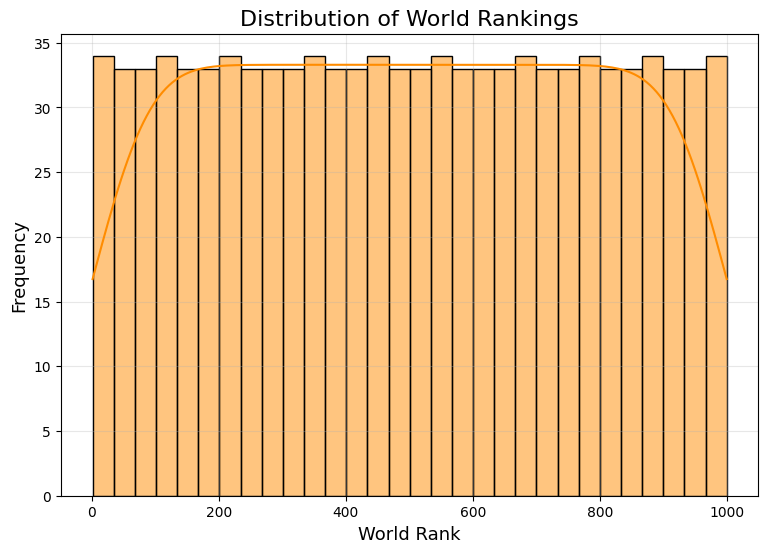

In [74]:
plt.figure(figsize=(9,6))

sns.histplot(
    data=table2,
    x='World Rank',
    bins=30,
    kde=True,
    color='darkorange'
)

plt.title('Distribution of World Rankings', fontsize=16)

plt.xlabel('World Rank', fontsize=13)

plt.ylabel('Frequency', fontsize=13)

plt.grid(alpha=0.3)

plt.show()

Distribution of World Rankings

Objective
This visualization explores the distribution of universities according to their global rankings.
Observation
Most universities are concentrated in the middle and lower ranking positions, while relatively few universities occupy the highest global ranks.
The distribution is clearly skewed because obtaining a top global ranking is highly competitive.
Insight
Only a small group of universities consistently achieve top international positions.
Conclusion
The global ranking system is highly competitive, and only a limited number of institutions belong to the world's elite universities.

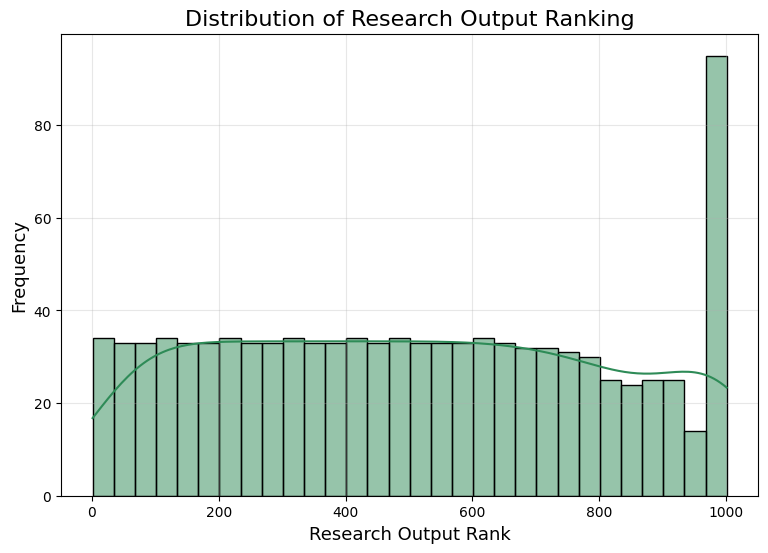

In [73]:
plt.figure(figsize=(9,6))

sns.histplot(
    data=table2,
    x='Research Output',
    bins=30,
    kde=True,
    color='seagreen'
)

plt.title('Distribution of Research Output Ranking', fontsize=16)

plt.xlabel('Research Output Rank', fontsize=13)

plt.ylabel('Frequency', fontsize=13)

plt.grid(alpha=0.3)

plt.show()

Distribution of Research Output Rankings

Objective
The objective is to analyze how research performance is distributed among universities.
Observation
Most universities have average research rankings, whereas only a few institutions demonstrate exceptional research productivity.
The distribution indicates noticeable variation in research performance.
Insight
Research productivity differs considerably across universities, highlighting differences in research capacity and academic resources.
Conclusion
Research output is one of the major characteristics that distinguishes top universities from the rest of the dataset.

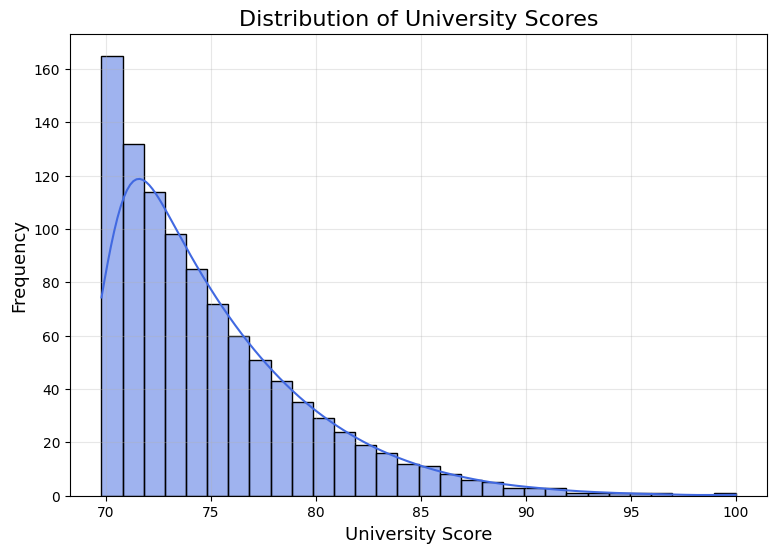

In [21]:
plt.figure(figsize=(9,6))

sns.histplot(
    data=table2,
    x='Score',
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title('Distribution of University Scores', fontsize=16)

plt.xlabel('University Score', fontsize=13)

plt.ylabel('Frequency', fontsize=13)

plt.grid(alpha=0.3)

plt.show()

Distribution of University Scores

Objective
The purpose of this visualization is to examine how university scores are distributed across the dataset.
Observation
The histogram shows that most universities are concentrated within the middle score range, while only a relatively small number of universities achieve exceptionally high scores.
The KDE curve indicates that the distribution is not perfectly symmetric and is slightly skewed.
Insight
This result suggests that outstanding universities represent only a small proportion of the dataset, whereas the majority of institutions achieve moderate overall scores.
Conclusion
University performance is not evenly distributed. Only a limited number of universities obtain very high scores, making them significantly different from the majority of institutions.

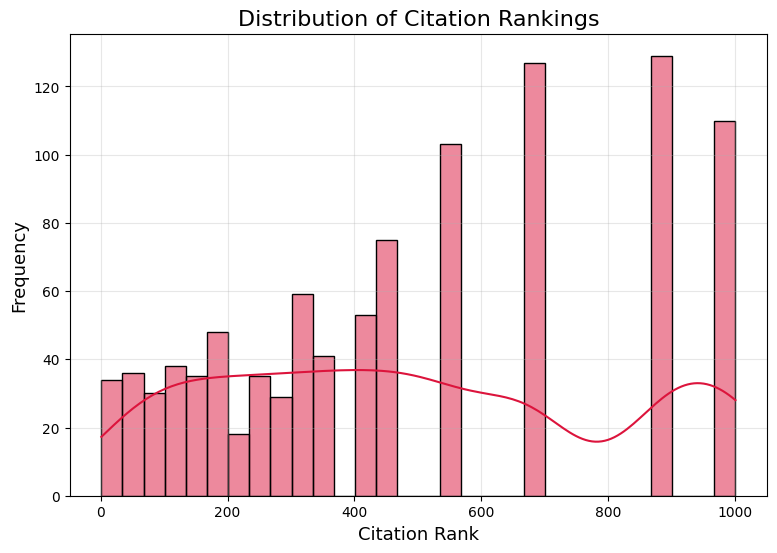

In [22]:
plt.figure(figsize=(9,6))

sns.histplot(
    data=table2,
    x='Citations',
    bins=30,
    kde=True,
    color='crimson'
)

plt.title('Distribution of Citation Rankings', fontsize=16)

plt.xlabel('Citation Rank', fontsize=13)

plt.ylabel('Frequency', fontsize=13)

plt.grid(alpha=0.3)

plt.show()

Distribution of Citation Rankings

Objective
This visualization examines how citation rankings are distributed among universities.
Observation
Most universities receive moderate citation rankings, while only a small number achieve exceptionally high citation impact.
The distribution is slightly skewed, indicating unequal scientific influence.
Insight
Highly cited universities are relatively rare and generally represent institutions with strong research visibility.
Conclusion
Citation impact is concentrated among a limited number of universities, emphasizing the unequal distribution of scientific influence.

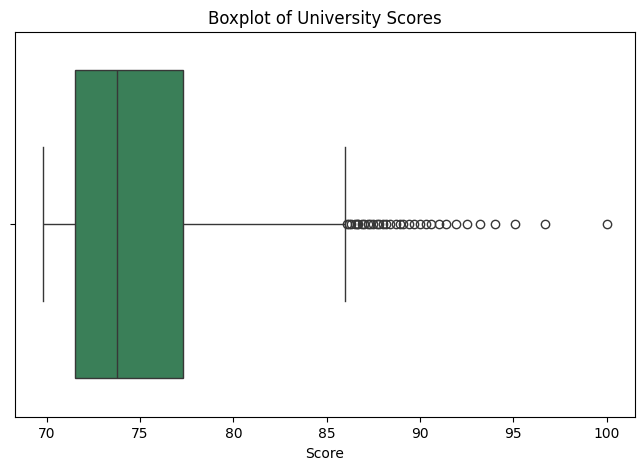

In [75]:
plt.figure(figsize=(8,5))

sns.boxplot(x=table2['Score'],color="seagreen")

plt.title('Boxplot of University Scores')
plt.xlabel('Score')

plt.show()

Boxplot of University Scores

Objective
The purpose of this boxplot is to identify the spread of university scores and detect potential outliers.
Observation
The boxplot reveals several observations located outside the whiskers, indicating the presence of outliers.
These universities have significantly different scores compared with the majority of institutions.
Insight
Outliers most likely represent internationally recognized universities with exceptional academic performance.
Conclusion
Although most universities have comparable scores, a small number of institutions clearly outperform the rest of the dataset.

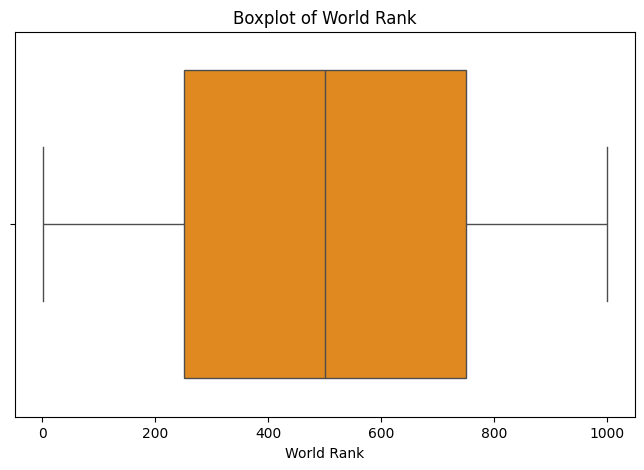

In [76]:
plt.figure(figsize=(8,5))

sns.boxplot(x=table2['World Rank'],color="darkorange")

plt.title('Boxplot of World Rank')
plt.xlabel('World Rank')

plt.show()

Boxplot of World Rankings

Objective
This boxplot evaluates the distribution of world rankings and highlights extreme observations.
Observation
Several universities appear as outliers, reflecting institutions with exceptionally high or low global rankings.
The ranking distribution covers a wide range.
Insight
The significant spread demonstrates that universities vary greatly in their international competitiveness.
Conclusion
Global university rankings are highly dispersed, indicating considerable differences in academic performance across institutions.

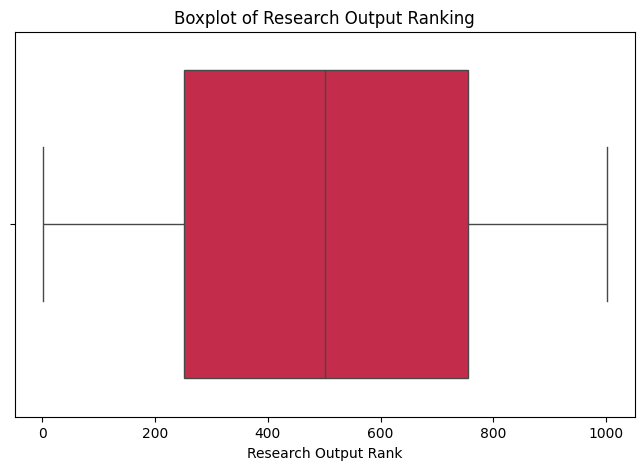

In [77]:
plt.figure(figsize=(8,5))

sns.boxplot(x=table2['Research Output'],color="crimson")

plt.title('Boxplot of Research Output Ranking')
plt.xlabel('Research Output Rank')

plt.show()

Boxplot of Research Output Rankings

Objective
The objective of this boxplot is to investigate the distribution of research output rankings and identify potential outliers.
Observation
The plot indicates that most universities are concentrated within a specific range of research rankings, while several institutions appear as outliers.
These outliers represent universities with exceptionally strong or weak research performance.
Insight
The existence of outliers suggests considerable variation in research productivity among universities.
Conclusion
Research output is not uniformly distributed. A relatively small number of universities demonstrate outstanding research performance compared with the majority of institutions.

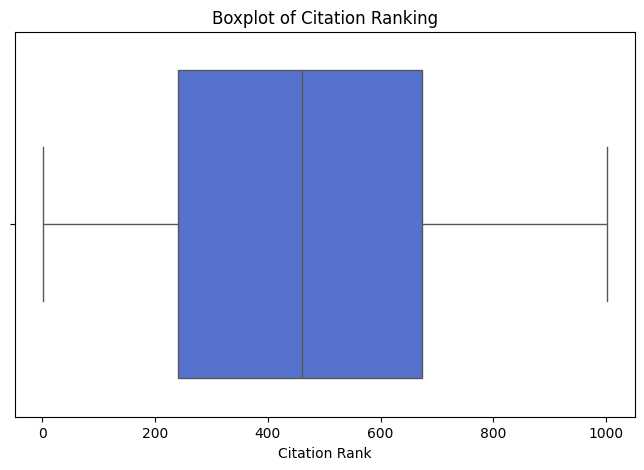

In [78]:
plt.figure(figsize=(8,5))

sns.boxplot(x=table2['Citations'],color="royalblue")

plt.title('Boxplot of Citation Ranking')
plt.xlabel('Citation Rank')

plt.show()

Boxplot of Citation Rankings

Objective
The purpose of this visualization is to identify the spread of citation rankings and detect extreme observations.
Observation
Several universities are located outside the whiskers, indicating unusually high or low citation rankings.
This demonstrates that citation performance varies substantially among institutions.
Insight
Highly cited universities are relatively uncommon and generally represent institutions with significant international research impact.
Conclusion
Citation performance is concentrated among a limited number of universities, highlighting differences in scientific visibility and influence.

C:\Users\ramin\AppData\Local\Temp\ipykernel_6660\2000274511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


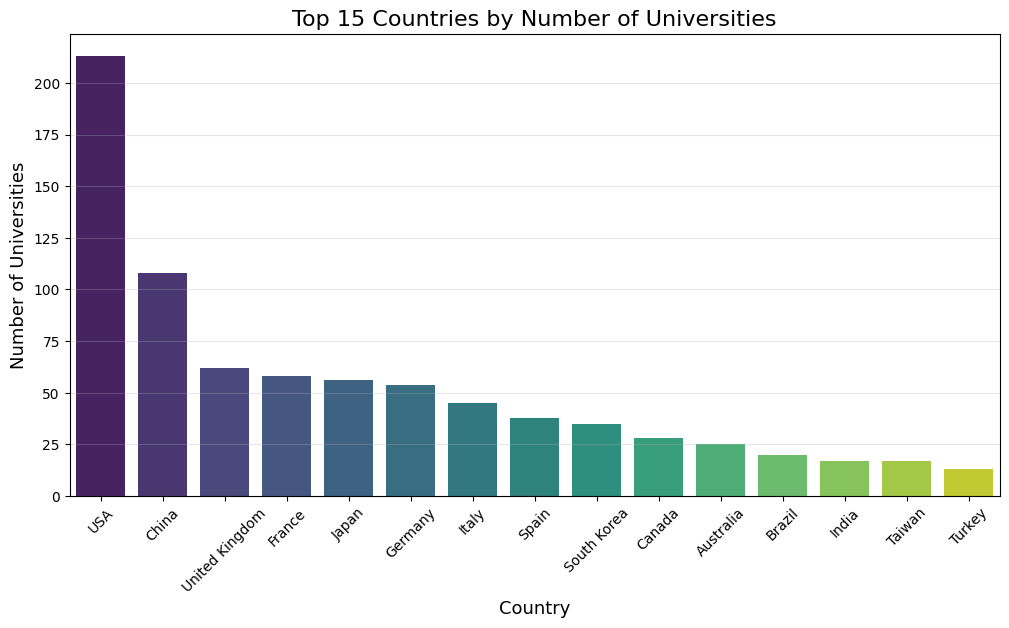

In [86]:
top15_country = table2['Location'].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top15_country.index,
    y=top15_country.values,
    palette='viridis'
)

plt.title('Top 15 Countries by Number of Universities', fontsize=16)

plt.xlabel('Country', fontsize=13)

plt.ylabel('Number of Universities', fontsize=13)

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.show()

Top 15 Countries by Number of Universities

Objective
This bar chart compares the number of ranked universities across the top fifteen countries.
Observation
The results show that a small number of countries contribute a large proportion of universities to the global ranking.
Several countries clearly dominate the dataset in terms of university representation.
Insight
Countries with more ranked universities generally have larger higher education systems and stronger research infrastructures.
Conclusion
The distribution of ranked universities is uneven across countries, with a few nations contributing the majority of institutions included in the ranking.

C:\Users\ramin\AppData\Local\Temp\ipykernel_6660\1770702469.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


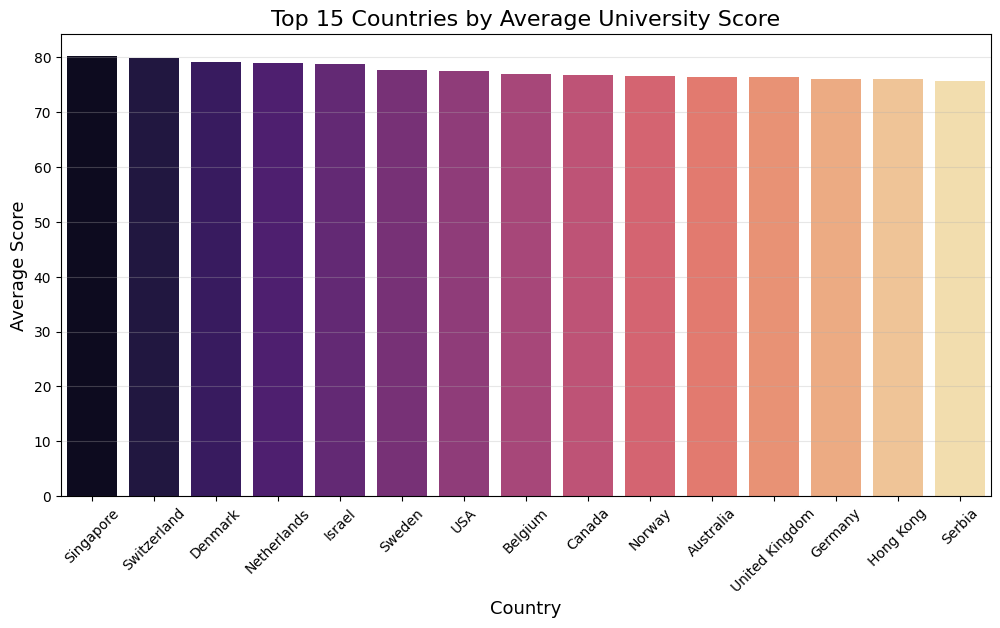

In [84]:
country_score = (
    table2.groupby('Location')['Score']
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_score.index,
    y=country_score.values,
    palette='magma'
)

plt.title('Top 15 Countries by Average University Score', fontsize=16)

plt.xlabel('Country', fontsize=13)

plt.ylabel('Average Score', fontsize=13)

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.show()

Average University Score by Country

Objective
The objective is to compare the average university score among different countries.
Observation
Noticeable differences exist in the average scores across countries.
Some countries consistently achieve higher average scores than others.
Insight
A greater number of universities does not necessarily imply a higher average performance.
Quality and quantity should therefore be evaluated separately.
Conclusion
Average university performance varies considerably across countries, suggesting differences in educational quality, research investment, and academic competitiveness.

C:\Users\ramin\AppData\Local\Temp\ipykernel_6660\2974412008.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


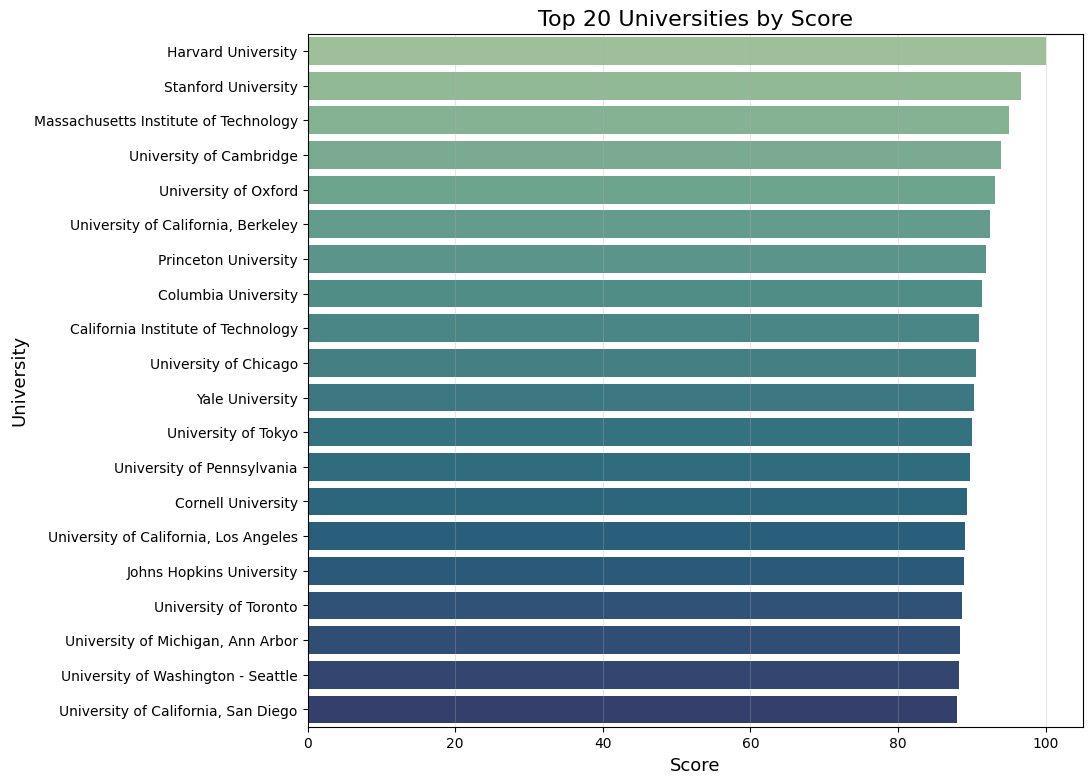

In [85]:
top20 = table2.sort_values(
    by='Score',
    ascending=False
).head(20)

plt.figure(figsize=(10,9))

sns.barplot(
    data=top20,
    x='Score',
    y='Institution',
    palette='crest'
)

plt.title('Top 20 Universities by Score', fontsize=16)

plt.xlabel('Score', fontsize=13)

plt.ylabel('University', fontsize=13)

plt.grid(axis='x', alpha=0.3)

plt.show()

Top 20 Universities by Overall Score

Objective
This visualization highlights the highest-performing universities based on their overall scores.
Observation
The leading universities achieve noticeably higher scores than many other institutions in the dataset.
Although the top universities are highly competitive, small differences exist among the highest-ranked institutions.
Insight
These universities consistently perform well across multiple ranking indicators, including research output, citations, faculty quality, and academic influence.
Conclusion
The highest-ranked universities distinguish themselves through balanced excellence across several evaluation criteria rather than outstanding performance in only one area.

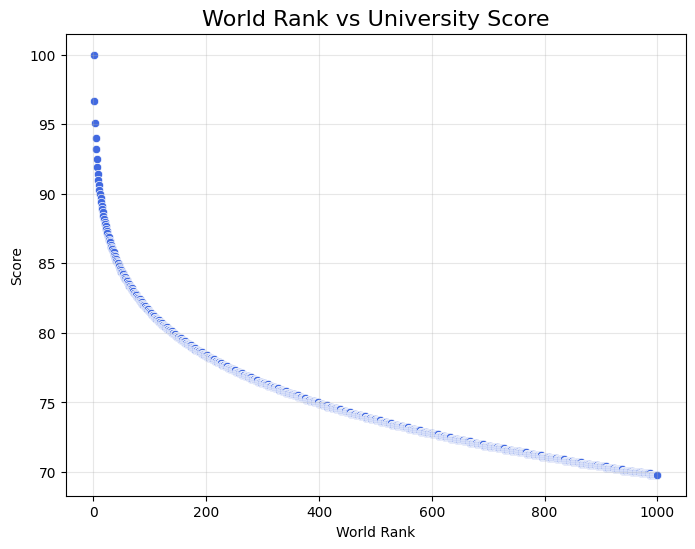

In [83]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=table2,
    x='World Rank',
    y='Score',
    color='royalblue'
)

plt.title('World Rank vs University Score', fontsize=16)

plt.xlabel('World Rank')

plt.ylabel('Score')

plt.grid(alpha=0.3)

plt.show()

Relationship Between World Rank and University Score

Objective
This scatter plot investigates the relationship between global ranking and the overall university score.
Observation
A clear negative relationship can be observed. Universities with better global rankings (lower rank values) generally achieve higher overall scores.
Insight
The strong relationship indicates that the overall score is closely associated with global ranking performance.
Conclusion
World Rank is one of the strongest indicators of overall university quality within this dataset.

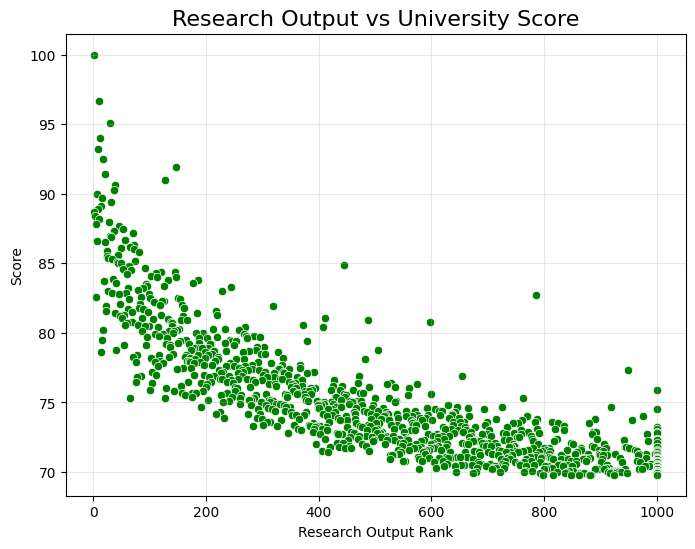

In [82]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=table2,
    x='Research Output',
    y='Score',
    color='green'
)

plt.title('Research Output vs University Score', fontsize=16)

plt.xlabel('Research Output Rank')

plt.ylabel('Score')

plt.grid(alpha=0.3)

plt.show()

Research Output and University Score

Objective
The purpose of this visualization is to examine the relationship between research productivity and overall university performance.
Observation
Universities with stronger research rankings tend to obtain higher overall scores.
Although some variation exists, the overall relationship is clearly visible.
Insight
Research productivity plays a major role in determining university performance.
Conclusion
Improving research output is strongly associated with achieving higher university scores.

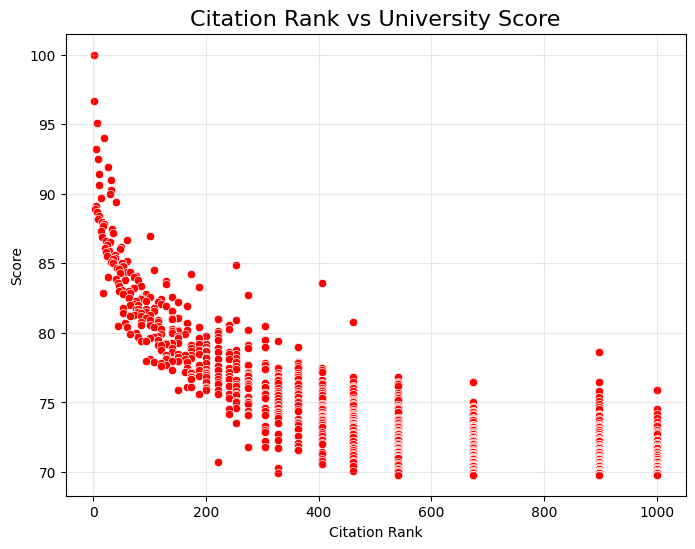

In [81]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=table2,
    x='Citations',
    y='Score',
    color='red'
)

plt.title('Citation Rank vs University Score', fontsize=16)

plt.xlabel('Citation Rank')

plt.ylabel('Score')

plt.grid(alpha=0.3)

plt.show()

Relationship Between Citation Ranking and University Score

Objective
The purpose of this scatter plot is to investigate whether citation performance is associated with the overall university score.
Observation
The visualization reveals a clear relationship between citation ranking and university score. Universities with better citation rankings generally achieve higher overall scores, although a few exceptions are present.
Insight
Citation impact reflects the scientific visibility and influence of a university's research. Institutions with highly cited publications tend to perform better in the overall ranking system.
Conclusion
Citation performance is one of the strongest contributors to university quality. Increasing research impact through highly cited publications can significantly improve a university's overall performance.

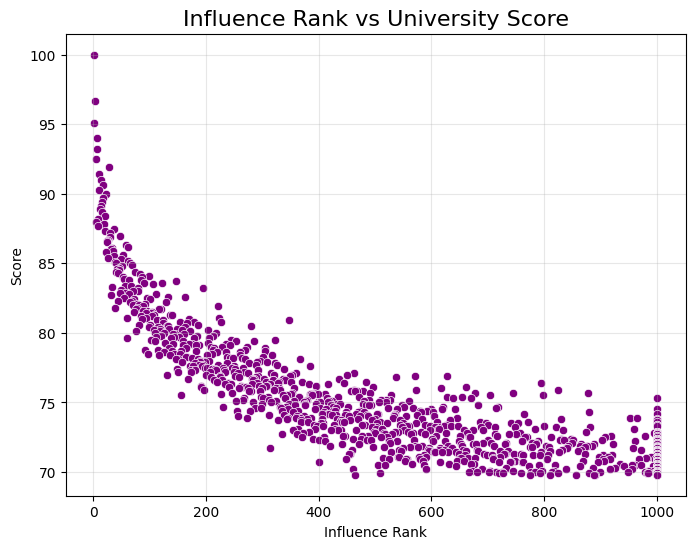

In [80]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=table2,
    x='Influence',
    y='Score',
    color='purple'
)

plt.title('Influence Rank vs University Score', fontsize=16)

plt.xlabel('Influence Rank')

plt.ylabel('Score')

plt.grid(alpha=0.3)

plt.show()

Relationship Between Research Influence and University Score

Objective
This visualization examines the relationship between research influence and the overall university score.
Observation
A noticeable relationship exists between the two variables. Universities with stronger research influence generally receive higher overall scores.
Insight
Research influence measures how significantly a university contributes to the scientific community. Institutions producing influential research consistently achieve better overall performance.
Conclusion
Research influence is an important indicator of university excellence and plays a significant role in determining the overall score.

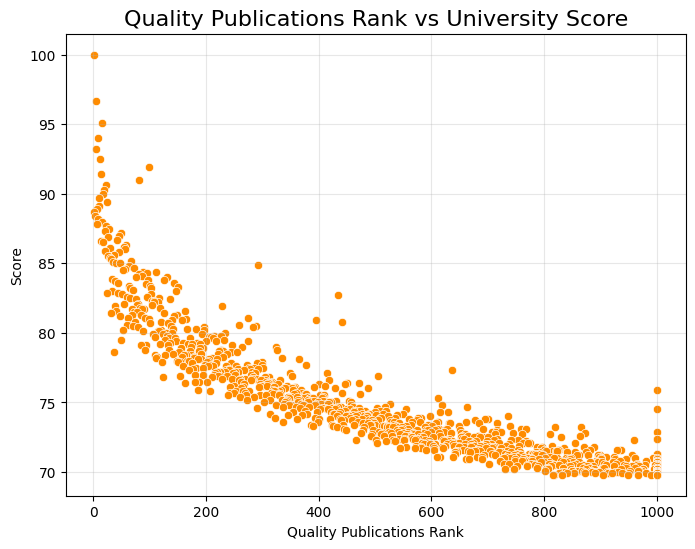

In [79]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=table2,
    x='Quality Publications',
    y='Score',
    color='darkorange'
)

plt.title('Quality Publications Rank vs University Score', fontsize=16)

plt.xlabel('Quality Publications Rank')

plt.ylabel('Score')

plt.grid(alpha=0.3)

plt.show()

Relationship Between Publication Quality and University Score

Objective
The objective of this visualization is to evaluate whether publication quality is associated with university performance.
Observation
The scatter plot demonstrates that universities with better publication quality rankings generally obtain higher overall scores.
Although a few universities deviate from the overall trend, the relationship remains clear.
Insight
Publishing high-quality scientific papers contributes substantially to institutional reputation and academic success.
Conclusion
Publication quality is strongly associated with university performance and represents an important component of global university rankings.

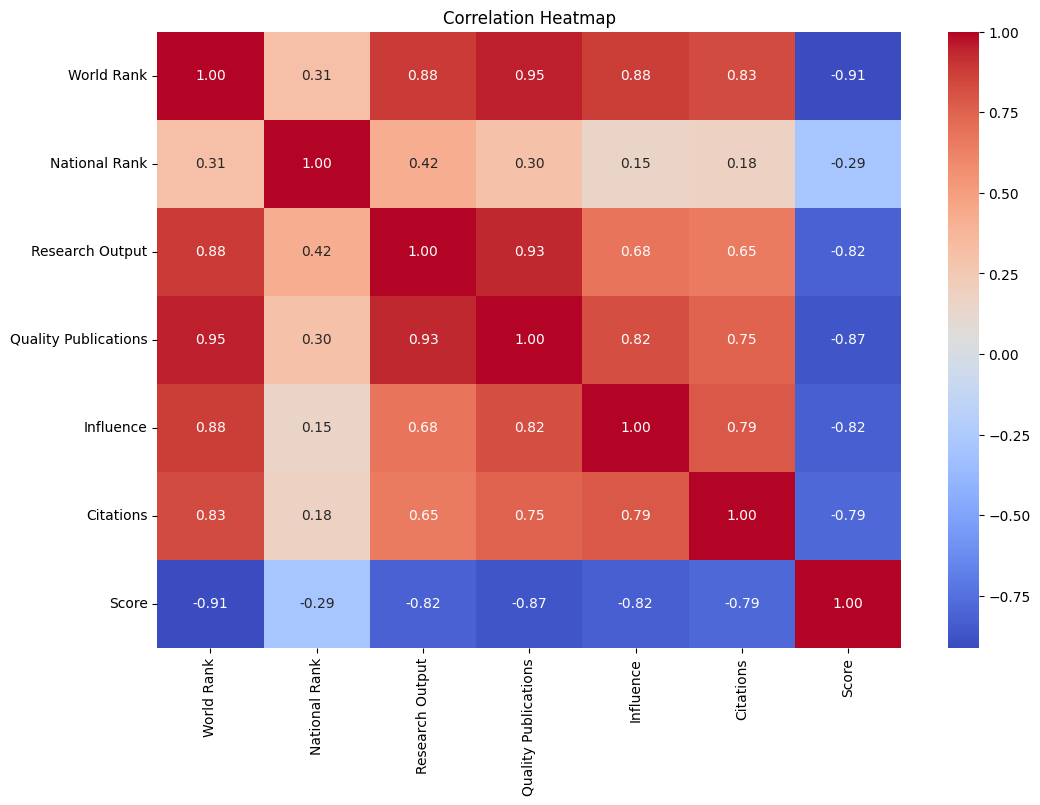

In [39]:
plt.figure(figsize=(12,8))

corr = table2[
    [
        'World Rank',
        'National Rank',
        'Research Output',
        'Quality Publications',
        'Influence',
        'Citations',
        'Score'
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

Correlation Analysis

Objective
The correlation heatmap is used to investigate the relationships among the numerical variables in the dataset.
Observation
Several ranking indicators exhibit strong positive or negative correlations. Variables related to research performance, citations, influence, and publication quality show meaningful relationships with the overall university score.
World Rank presents a strong negative correlation with Score because lower ranking values represent better university positions.
Insight
The heatmap confirms that university performance is influenced by multiple interconnected indicators rather than a single factor.
Research-related variables appear to be the most influential components of overall university quality.
Conclusion
The correlation analysis demonstrates that research productivity, citation impact, publication quality, and scientific influence are the key drivers of university performance within this dataset.

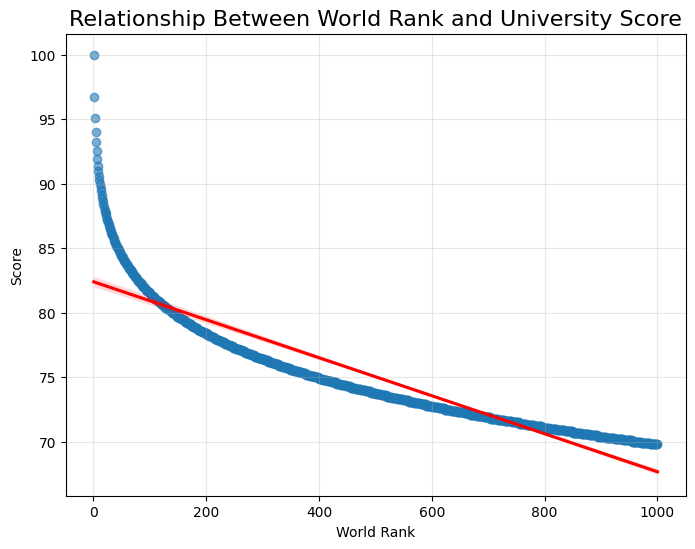

In [40]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=table2,
    x='World Rank',
    y='Score',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.title('Relationship Between World Rank and University Score', fontsize=16)
plt.xlabel('World Rank')
plt.ylabel('Score')

plt.grid(alpha=0.3)

plt.show()

Regression Analysis: World Rank vs University Score

Objective
The purpose of this regression plot is to investigate the relationship between World Rank and the Overall University Score while fitting a regression line to identify the overall trend.
Observation
The regression line shows a strong negative relationship between the two variables. Universities with lower world ranking values (better rankings) generally achieve higher overall scores.
Insight
The regression line confirms that global ranking is strongly associated with university performance. The relatively small dispersion around the trend line indicates a consistent relationship.
Conclusion
World Rank is one of the strongest predictors of the Overall Score. Universities with better global rankings consistently obtain higher performance scores.

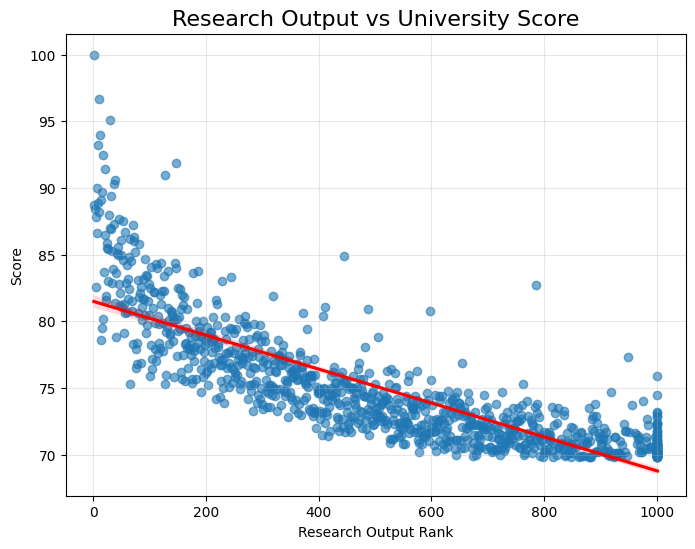

In [41]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=table2,
    x='Research Output',
    y='Score',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.title('Research Output vs University Score', fontsize=16)
plt.xlabel('Research Output Rank')
plt.ylabel('Score')

plt.grid(alpha=0.3)

plt.show()

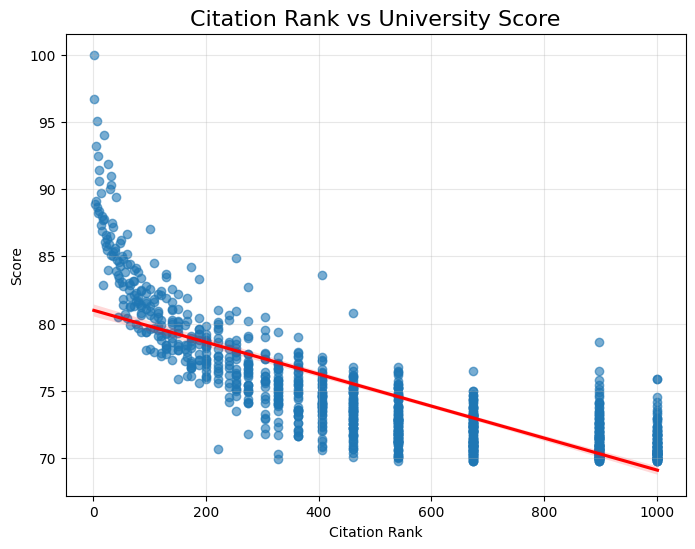

In [42]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=table2,
    x='Citations',
    y='Score',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.title('Citation Rank vs University Score', fontsize=16)
plt.xlabel('Citation Rank')
plt.ylabel('Score')

plt.grid(alpha=0.3)

plt.show()

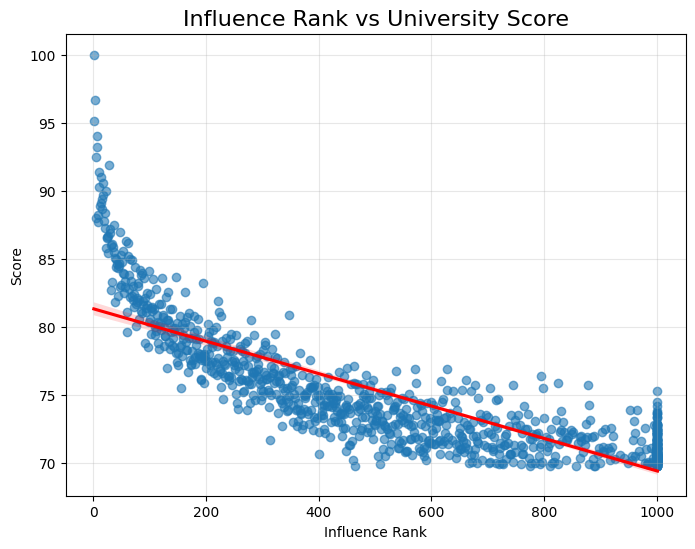

In [43]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=table2,
    x='Influence',
    y='Score',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.title('Influence Rank vs University Score', fontsize=16)
plt.xlabel('Influence Rank')
plt.ylabel('Score')

plt.grid(alpha=0.3)

plt.show()

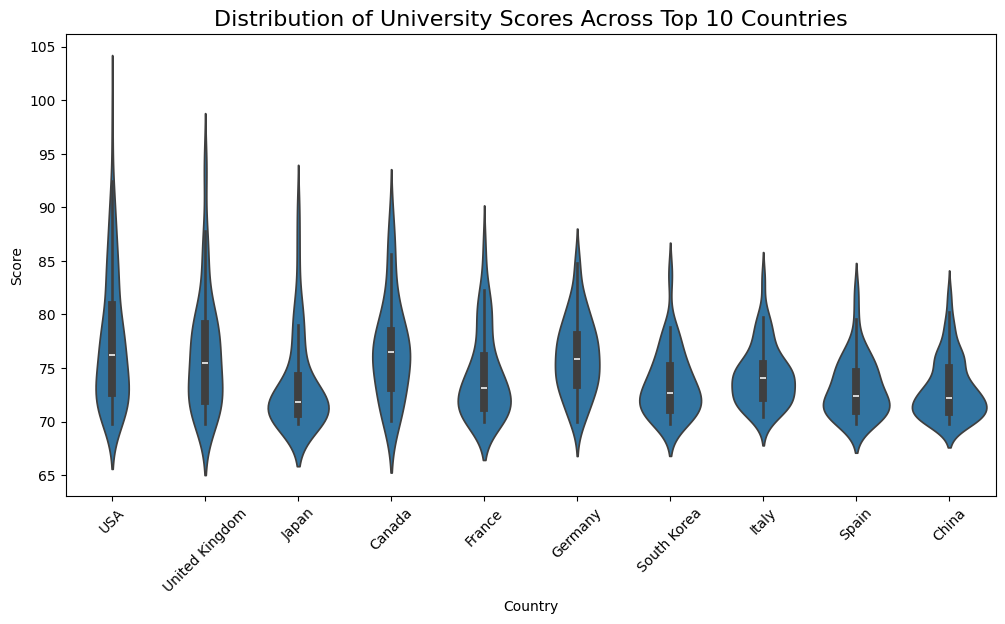

In [44]:
top10 = table2['Location'].value_counts().head(10).index

table2_top10 = table2[table2['Location'].isin(top10)]

plt.figure(figsize=(12,6))

sns.violinplot(
    data=table2_top10,
    x='Location',
    y='Score'
)

plt.title('Distribution of University Scores Across Top 10 Countries', fontsize=16)

plt.xlabel('Country')

plt.ylabel('Score')

plt.xticks(rotation=45)

plt.show()

Distribution of University Scores Across Countries

Objective
The violin plot is used to compare the distribution of university scores among the top countries represented in the dataset.
Observation
The distributions differ noticeably across countries. Some countries display a wide spread of scores, while others have a more concentrated distribution.
The shape of each violin reveals both the density and variability of university performance within each country.
Insight
Countries with a narrow distribution tend to have more consistent university performance, whereas wider distributions indicate greater diversity in institutional quality.
Conclusion
The violin plot provides a deeper understanding of score variability than traditional boxplots and highlights differences in higher education systems across countries.

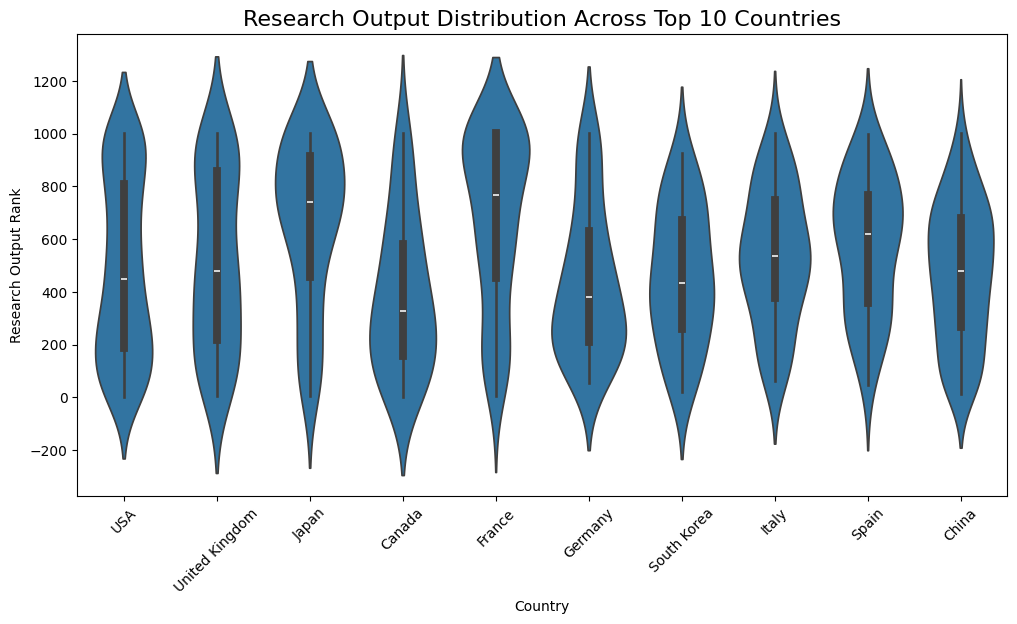

In [45]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=table2_top10,
    x='Location',
    y='Research Output'
)

plt.title('Research Output Distribution Across Top 10 Countries', fontsize=16)

plt.xlabel('Country')

plt.ylabel('Research Output Rank')

plt.xticks(rotation=45)

plt.show()

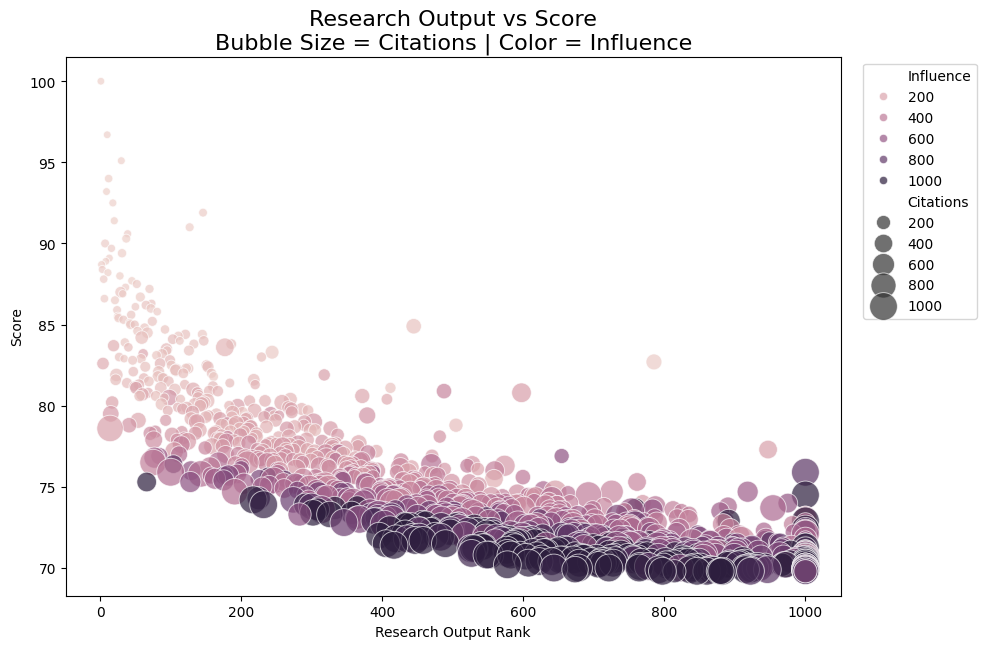

In [46]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=table2,
    x='Research Output',
    y='Score',
    size='Citations',
    hue='Influence',
    sizes=(30,400),
    alpha=0.7
)

plt.title('Research Output vs Score\nBubble Size = Citations | Color = Influence', fontsize=16)

plt.xlabel('Research Output Rank')

plt.ylabel('Score')

plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')

plt.show()

Bubble Chart Analysis

Objective
This visualization simultaneously explores the relationship among four variables: Research Output, University Score, Citation Ranking, and Research Influence.
The horizontal axis represents Research Output, the vertical axis represents the Overall Score, the bubble size indicates Citation Ranking, and the color represents Research Influence.
Observation
The bubble chart clearly illustrates that universities with strong research performance generally achieve higher scores. Larger and more distinctive bubbles tend to appear in the region corresponding to high-performing universities.
Insight
Analyzing multiple variables within a single visualization provides a more comprehensive understanding of university performance. The chart suggests that research productivity, citation impact, and scientific influence jointly contribute to institutional success.
Conclusion
University excellence cannot be explained by a single indicator. Instead, overall performance results from the combined effect of research productivity, citation impact, and scientific influence.

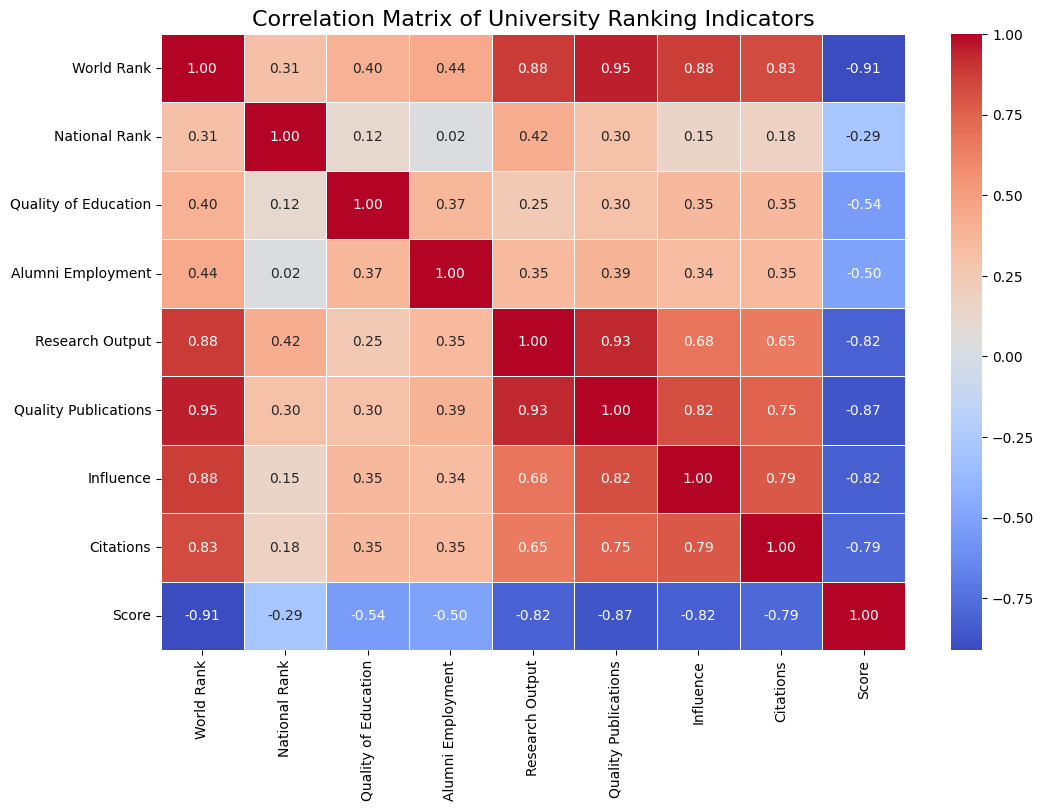

In [47]:
plt.figure(figsize=(12,8))

corr = table2[
    [
        'World Rank',
        'National Rank',
        'Quality of Education',
        'Alumni Employment',
        'Research Output',
        'Quality Publications',
        'Influence',
        'Citations',
        'Score'
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of University Ranking Indicators',
          fontsize=16)

plt.show()

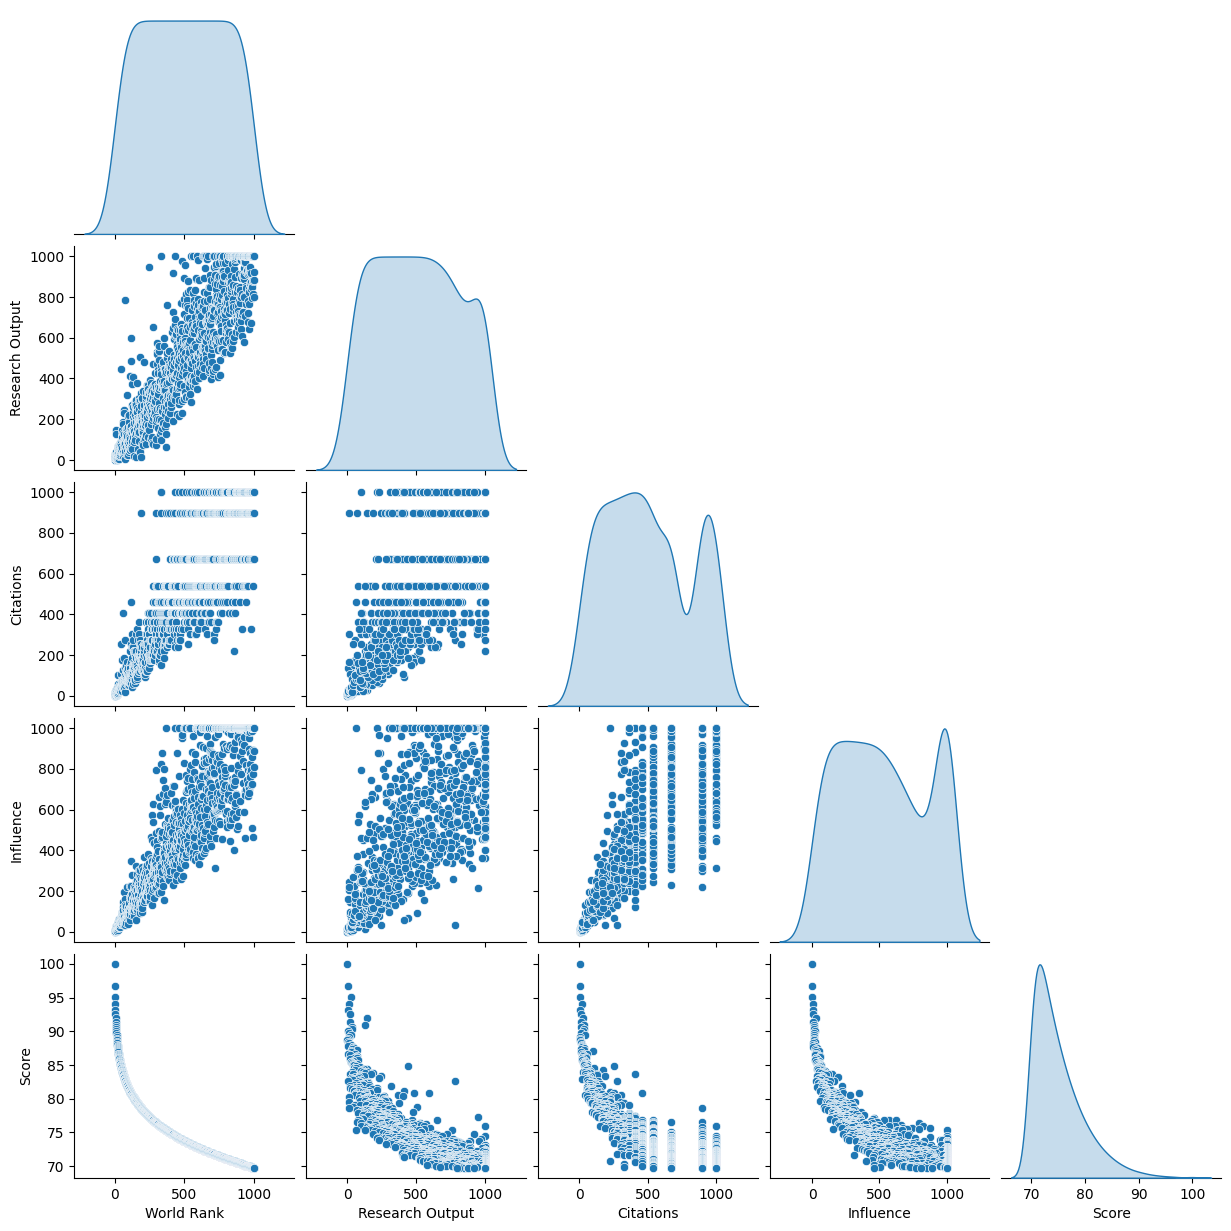

In [48]:
pair = table2[
    [
        'World Rank',
        'Research Output',
        'Citations',
        'Influence',
        'Score'
    ]
]

sns.pairplot(
    pair,
    corner=True,
    diag_kind='kde'
)

plt.show()

Pairwise Relationship Analysis

Objective
The pairplot is used to simultaneously explore the relationships and distributions among multiple numerical variables.
Observation
Strong relationships can be observed between several research-related variables and the Overall Score. Histograms along the diagonal reveal the individual distributions, while scatter plots illustrate pairwise correlations.
Insight
The pairplot provides a comprehensive overview of the dataset and helps identify variables that move together.
Conclusion
Research Output, Citations, Influence, and Overall Score exhibit meaningful relationships, confirming that university performance depends on multiple interconnected factors.

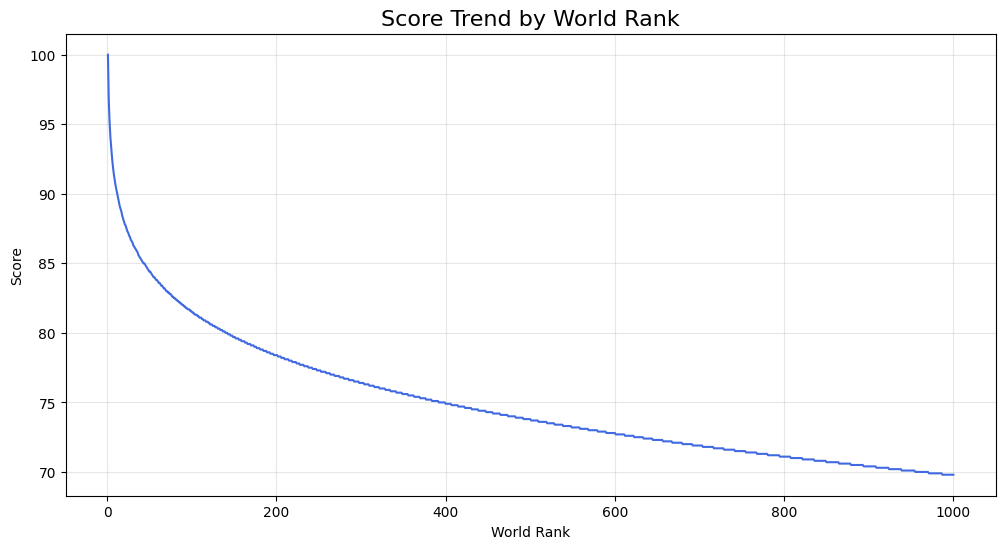

In [49]:
sorted_table2 = table2.sort_values('World Rank')

plt.figure(figsize=(12,6))

plt.plot(
    sorted_table2['World Rank'],
    sorted_table2['Score'],
    color='royalblue'
)

plt.title('Score Trend by World Rank',
          fontsize=16)

plt.xlabel('World Rank')

plt.ylabel('Score')

plt.grid(alpha=0.3)

plt.show()

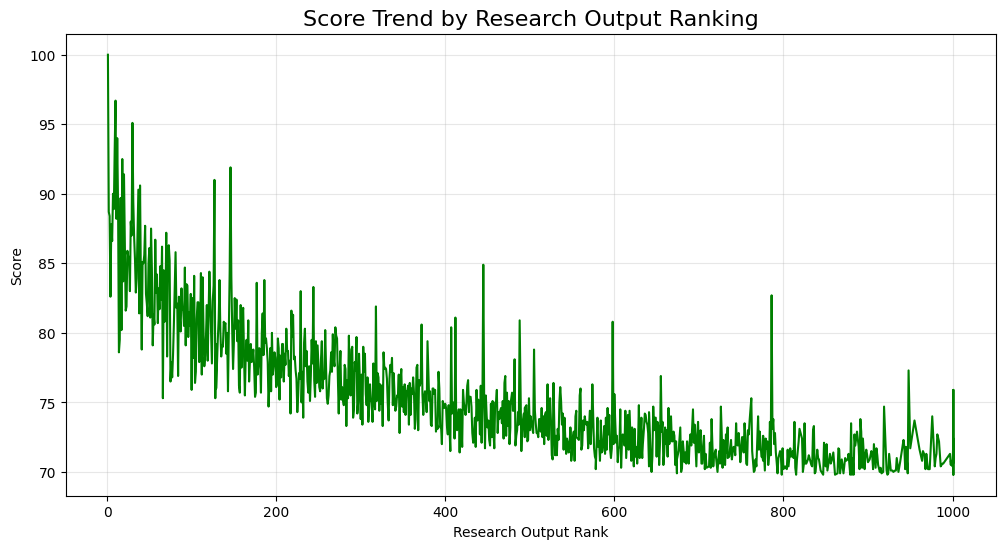

In [50]:
sorted_table2 = table2.sort_values('Research Output')

plt.figure(figsize=(12,6))

plt.plot(
    sorted_table2['Research Output'],
    sorted_table2['Score'],
    color='green'
)

plt.title('Score Trend by Research Output Ranking',
          fontsize=16)

plt.xlabel('Research Output Rank')

plt.ylabel('Score')

plt.grid(alpha=0.3)

plt.show()

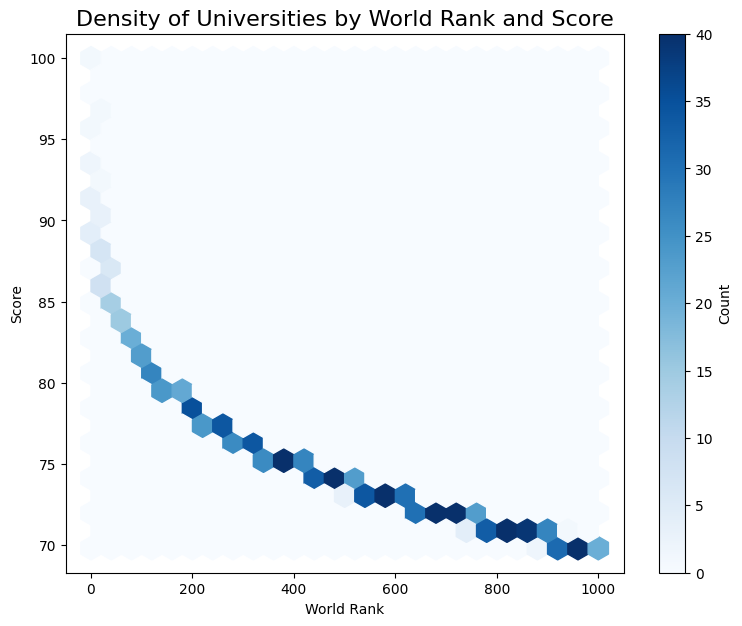

In [51]:
plt.figure(figsize=(9,7))

plt.hexbin(
    table2['World Rank'],
    table2['Score'],
    gridsize=25,
    cmap='Blues'
)

plt.colorbar(label='Count')

plt.title('Density of Universities by World Rank and Score',
          fontsize=16)

plt.xlabel('World Rank')

plt.ylabel('Score')

plt.show()

Density Analysis Using Hexbin Plot

Objective
The hexbin plot is designed to visualize the density of observations where many data points overlap.
Observation
High-density regions are clearly visible, showing where most universities are concentrated. Areas with fewer observations appear lighter.
Insight
Unlike a scatter plot, the hexbin plot reduces overplotting and makes dense regions easier to interpret.
Conclusion
Most universities are concentrated within a limited range of ranking and score values, while only a small number occupy extreme positions.

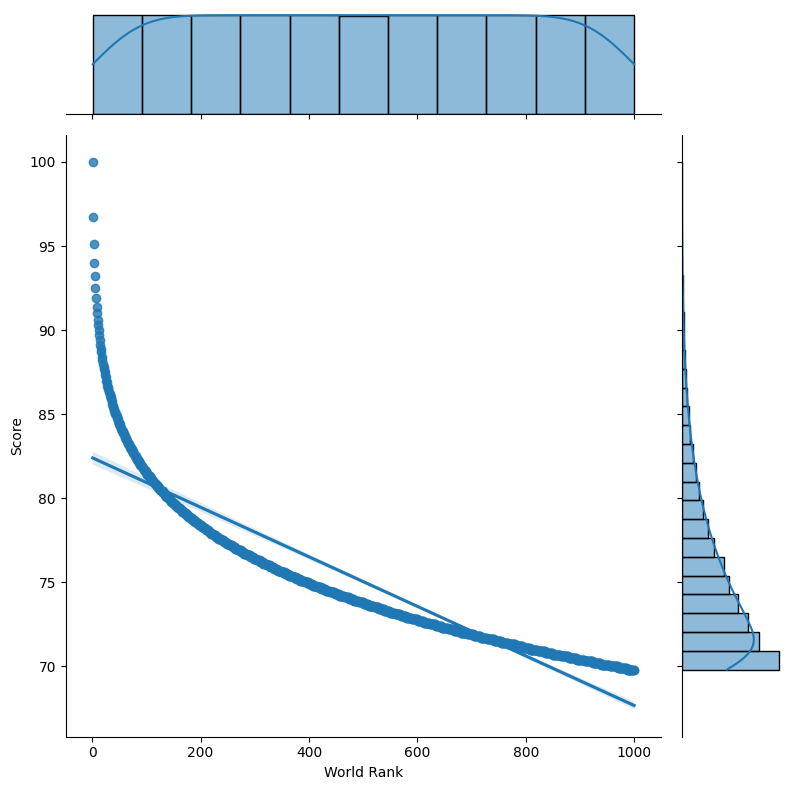

In [52]:
sns.jointplot(
    data=table2,
    x='World Rank',
    y='Score',
    kind='reg',
    height=8
)

plt.show()

Joint Distribution Analysis

Objective
The jointplot combines a scatter plot with marginal distributions to examine both the relationship between two variables and their individual distributions.
Observation
The visualization reveals a clear relationship between World Rank and Score while simultaneously showing the distribution of each variable.
Insight
This combined visualization provides a more complete understanding than a simple scatter plot by illustrating both correlation and distribution.
Conclusion
The jointplot confirms the strong association between university ranking and overall score while highlighting the underlying data distribution.

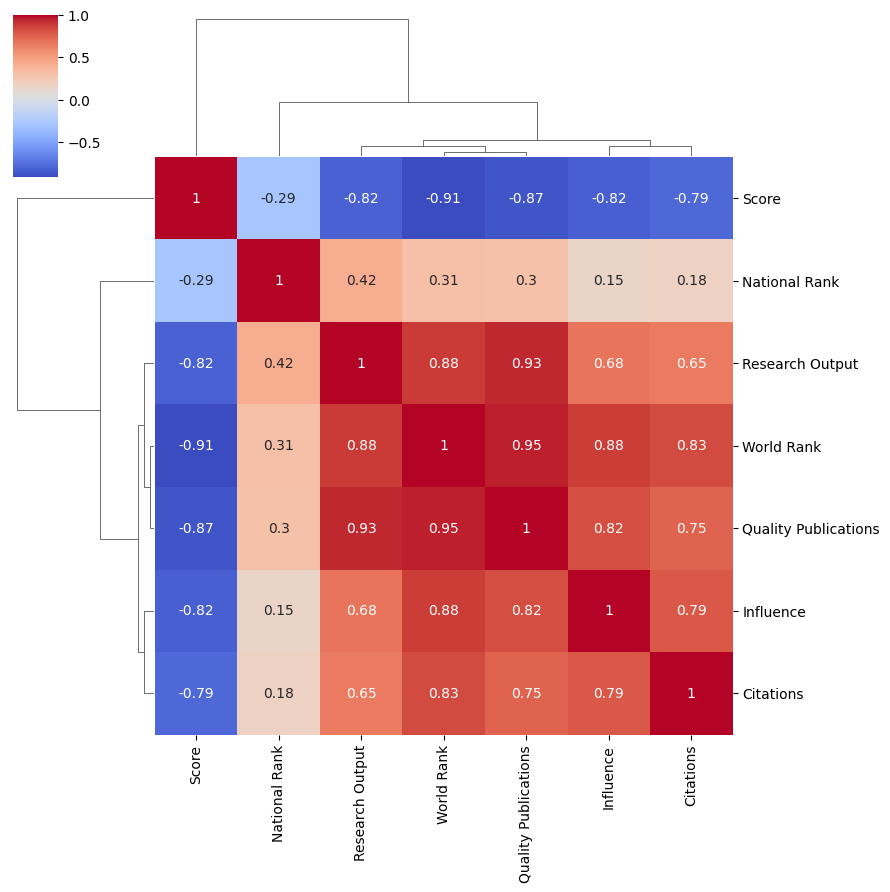

In [53]:
corr = table2[
[
'World Rank',
'National Rank',
'Research Output',
'Quality Publications',
'Influence',
'Citations',
'Score'
]
].corr()

sns.clustermap(
    corr,
    cmap='coolwarm',
    annot=True,
    figsize=(9,9)
)

plt.show()

Clustered Correlation Analysis

Objective
The clustered heatmap groups variables with similar correlation patterns to identify hidden structures within the dataset.
Observation
Research-related indicators are automatically clustered together because they exhibit similar correlation patterns.
Insight
Variables that belong to the same cluster contribute similarly to university performance and share common characteristics.
Conclusion
The clustered heatmap confirms that research productivity, citations, publication quality, and scientific influence form the core group of indicators affecting university rankings.

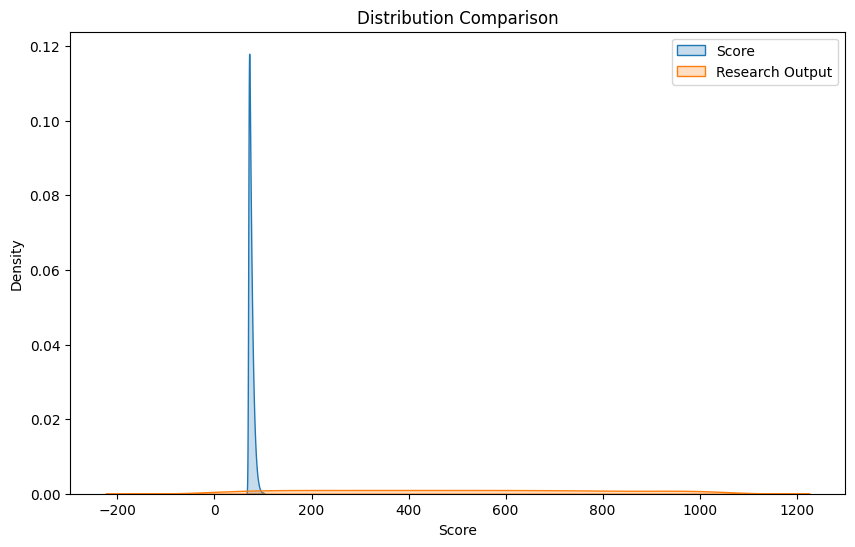

In [54]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    table2['Score'],
    label='Score',
    fill=True
)

sns.kdeplot(
    table2['Research Output'],
    label='Research Output',
    fill=True
)

plt.legend()

plt.title('Distribution Comparison')

plt.show()

Kernel Density Comparison

Objective
The purpose of this visualization is to compare the distributions of two numerical variables using Kernel Density Estimation (KDE).
Observation
The density curves reveal differences in the location, spread, and shape of the two variables.
Insight
Comparing density curves provides a clearer understanding of how the variables differ without relying solely on histograms.
Conclusion
The KDE comparison highlights similarities and differences in the distributions, helping identify variables with broader or narrower variability.

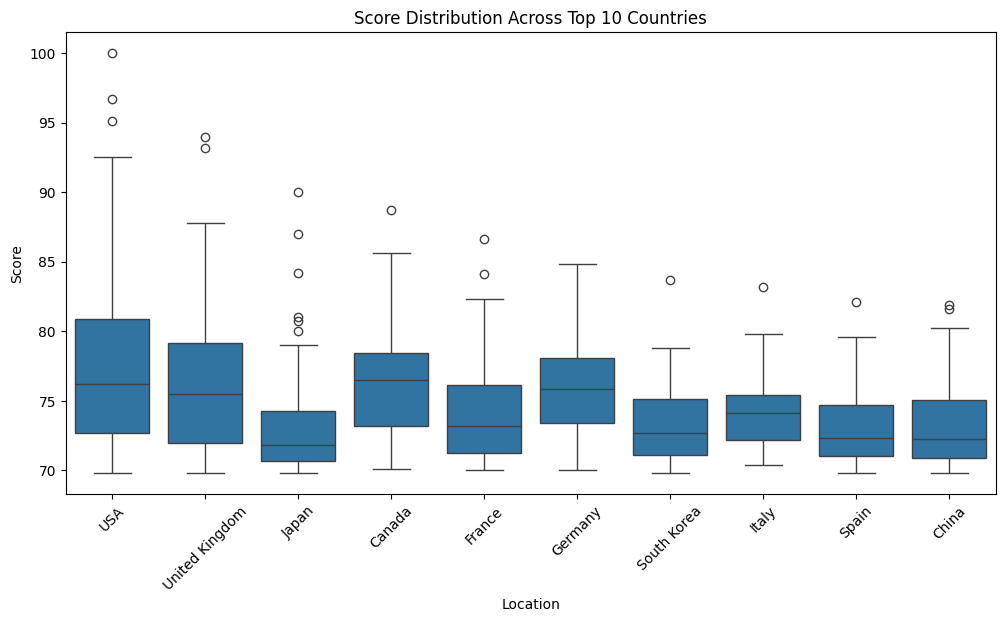

In [55]:
top10 = table2['Location'].value_counts().head(10).index

country = table2[table2['Location'].isin(top10)]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=country,
    x='Location',
    y='Score'
)

plt.xticks(rotation=45)

plt.title('Score Distribution Across Top 10 Countries')

plt.show()

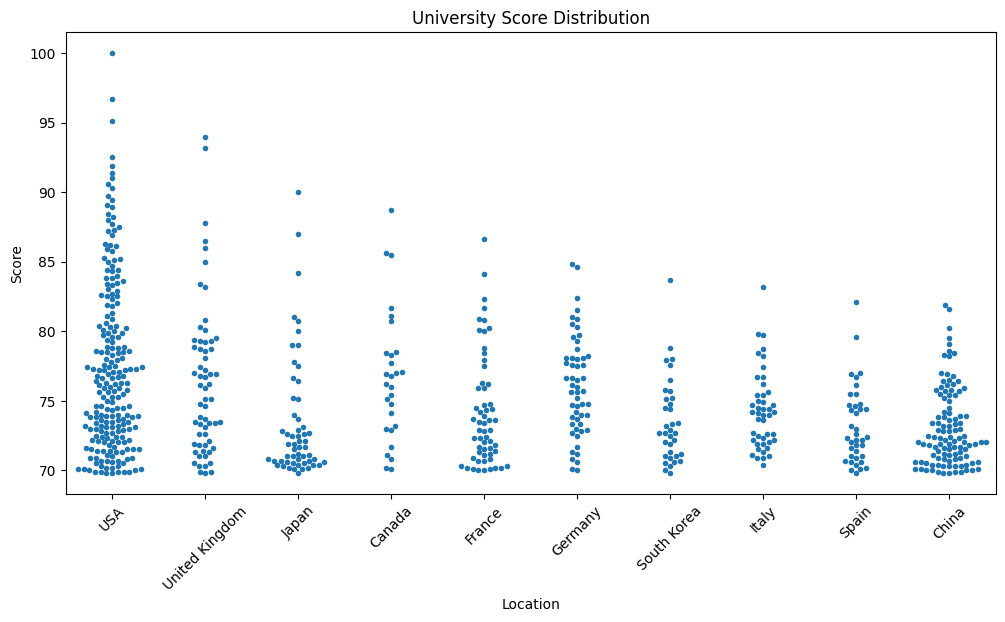

In [56]:
plt.figure(figsize=(12,6))

sns.swarmplot(
    data=country,
    x='Location',
    y='Score',
    size=4
)

plt.xticks(rotation=45)

plt.title('University Score Distribution')

plt.show()

Swarm Plot Analysis

Objective
The swarm plot visualizes every individual observation while comparing score distributions across different countries.
Observation
Unlike boxplots, every university is represented by a separate point, making it possible to observe the exact distribution and clustering of universities.
Some countries show tightly grouped scores, whereas others display a wider spread.
Insight
The swarm plot reveals the density of observations and highlights individual universities that differ from the majority.
Conclusion
University performance varies across countries, with some nations showing more consistent performance while others exhibit greater variability among institutions.

Final Conclusion

This project applied Exploratory Data Analysis (EDA) techniques to investigate the World University Ranking dataset.
The analysis included data cleaning, data type conversion, missing value inspection, descriptive statistics, and a variety of visualization techniques.
The results indicate that research-related indicators, including research output, citation impact, publication quality, and scientific influence, are strongly associated with overall university performance.
Correlation analysis confirmed that these variables are closely interconnected, while universities with better world rankings consistently achieved higher overall scores.
Furthermore, the analysis revealed noticeable differences in university performance across countries, emphasizing the diversity of global higher education systems.
Overall, this project demonstrates the importance of data preprocessing and visualization in extracting meaningful insights from complex educational datasets.